<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Assignment_Excersie_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##IMPORT LIBARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

import plotly.express as px

In [4]:
df = pd.read_csv("EFIplus_medit.csv", sep=';')

print(df.columns)

Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)


In [6]:
basins = ["Douro", "Tejo", "Mondego", "Minho"]

df = df[df["Catchment_name"].isin(basins)]

In [5]:
env_vars = [
    "Altitude",
    "Slope",
    "Mean_annual_temp",
    "Mean_annual_precipitation",
    "River_width",
    "Flow_velocity"
]

In [11]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [12]:
## DATA CLEANING
existing_env_vars = [var for var in env_vars if var in df.columns]

data = df[["Catchment_name"] + existing_env_vars].dropna()

X = data[existing_env_vars]
y = data["Catchment_name"]

In [26]:
##Standardize Variables and Run LDA
##LDA works better when variables are standardized.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=1) # Changed n_components to 1
X_lda = lda.fit_transform(X_scaled, y)

In [16]:
##. Create LDA Output DataFram
lda_df = pd.DataFrame(X_lda, columns=["LD1"])
lda_df["Catchment"] = y.values
lda_df["ID"] = lda_df.index

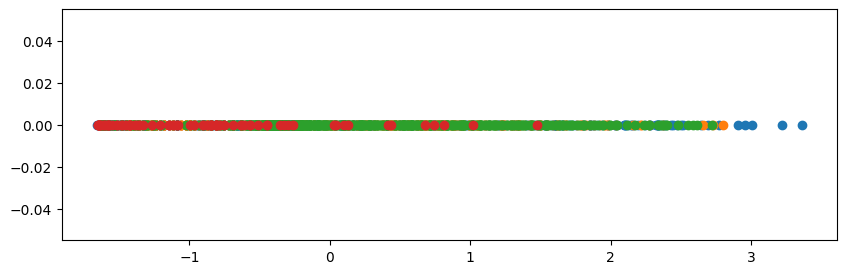

In [20]:

##STATIC LDA BIPLOT
plt.figure(figsize=(10, 3))

# scatter points
for basin in lda_df["Catchment"].unique():
    subset = lda_df[lda_df["Catchment"] == basin]
    plt.scatter(subset["LD1"], np.zeros_like(subset["LD1"]), label=basin) # Plot LD1 against zeros for 1D visualization


/tmp/ipykernel_1835/3522788897.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



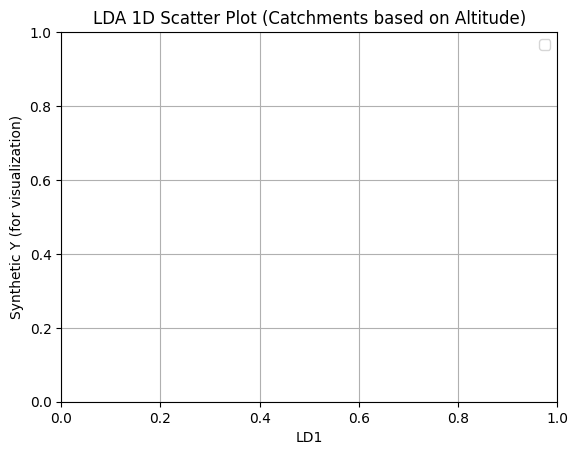

In [27]:

##Add environmental variable vectors
plt.xlabel("LD1")
plt.ylabel("Synthetic Y (for visualization)") # Changed y-axis label
plt.title("LDA 1D Scatter Plot (Catchments based on Altitude)") # Updated title
plt.legend()
plt.grid(True)
plt.show()

In [23]:

##INTERACTIVE LDA PLOT
lda_df['Dummy_Y'] = np.zeros(len(lda_df)) # Create a dummy Y column for 1D visualization

fig = px.scatter(
    lda_df,
    x="LD1",
    y="Dummy_Y", # Plot against the dummy Y column
    color="Catchment",
    hover_data=["ID"],
    title="Interactive LDA 1D Scatter Plot (Douro, Tejo, Mondego, Minho)"
)

fig.show()